# 04_概率分布-二项分布

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们来聊一个非常简单的概率分布：二项分布。

下面，从理论、案例和大家详细、清晰的聊聊\~

**二项分布**（Binomial Distribution）是一种离散概率分布，描述了在 $n$ 次独立的伯努利试验中成功的次数。每次试验中只有两种可能结果：成功（success）或失败（failure），成功的概率为 $p$，失败的概率为 $1-p$。

#### 二项分布的性质

**参数**: $n$（试验次数）和 $p$（成功的概率）。

**概率质量函数**: 二项分布的概率质量函数（PMF）定义如下：


$$
P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k = 0, 1, 2, \ldots, n
$$


其中：


$$
\binom{n}{k} = \frac{n!}{k!(n-k)!}
$$


表示从 $n$ 次试验中取出 $k$ 次成功的组合数。

**期望值和方差**:


$$
E(X) = np, \quad \text{Var}(X) = np(1-p)
$$


**应用场景**:

1. 医疗试验中记录某种治疗的成功次数。
2. 产品质量检测中，记录某批次产品的合格品数量。
3. A/B 测试中，记录点击广告的用户数量。

### 完整案例

使用 Python 代码来生成虚拟数据集，绘制二项分布的概率质量函数（PMF），并结合数据分析可视化解释其意义。

#### 案例1：广告点击率

假设一个在线广告的点击率 $p=0.3$，广告被展示给 $n=10$ 个用户。我们想分析这组数据中广告被点击的次数分布。

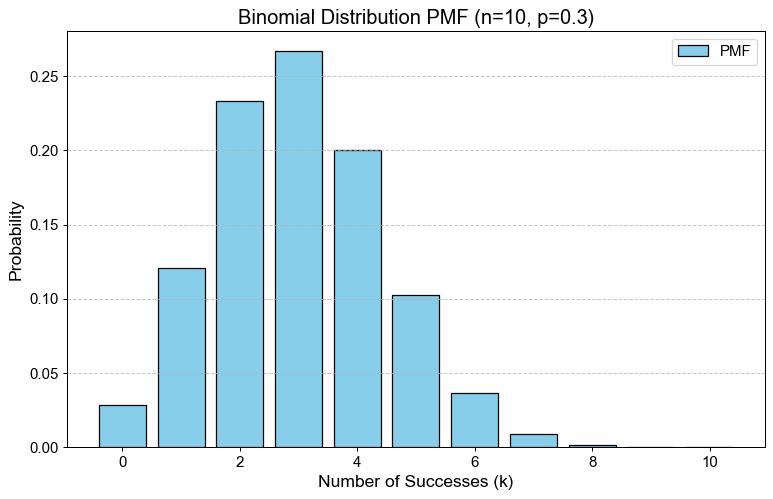

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parameters
n = 10  # Number of trials
p = 0.3  # Probability of success

# Generate binomial distribution
x = np.arange(0, n+1)
pmf = binom.pmf(x, n, p)

# Plotting PMF
plt.figure(figsize=(10, 6))
plt.bar(x, pmf, color='skyblue', edgecolor='black', label='PMF')
plt.title('Binomial Distribution PMF (n=10, p=0.3)', fontsize=16)
plt.xlabel('Number of Successes (k)', fontsize=14)
plt.ylabel('Probability', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_003.png)

图中显示了 $n=10$, $p=0.3$ 条件下二项分布的概率质量函数。横轴为点击广告的次数（成功次数），纵轴为对应概率。概率分布的高峰在 $k=3$，表明广告被点击 3 次的概率最高，符合 $E(X) = np = 3$。

#### 案例2：质量检测

假设某工厂生产的零件有 5% 的概率是次品。从 50 个零件中随机抽取一批，记录次品的数量分布。

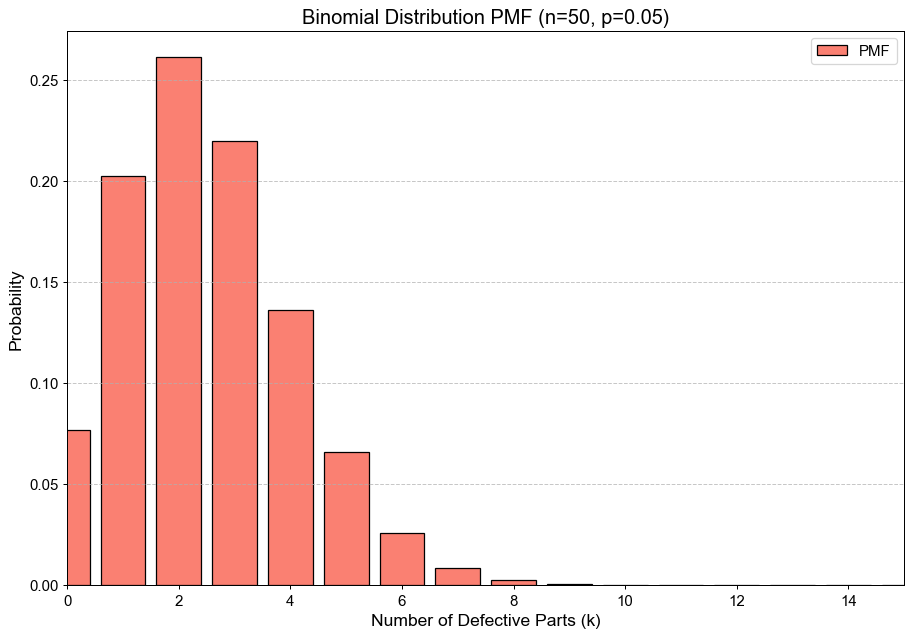

In [3]:
# Parameters
n = 50  # Number of trials
p = 0.05  # Probability of success

# Generate binomial distribution
x = np.arange(0, n+1)
pmf = binom.pmf(x, n, p)

# Plotting PMF
plt.figure(figsize=(12, 8))
plt.bar(x, pmf, color='salmon', edgecolor='black', label='PMF')
plt.title('Binomial Distribution PMF (n=50, p=0.05)', fontsize=16)
plt.xlabel('Number of Defective Parts (k)', fontsize=14)
plt.ylabel('Probability', fontsize=14)
plt.xlim(0, 15)  # Focus on the range of interest
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_004.png)

图中显示了 $n=50, p=0.05$ 条件下的次品数量分布。大部分概率集中在 $k=0$ 和 $k=1$ 附近，表明次品数量很少。这种分布适用于分析高质量生产工艺的性能。

### 数据分析图的进一步探索

我们通过模拟和数据分析，生成虚拟数据集并探索其特性。

##### 虚拟数据集模拟

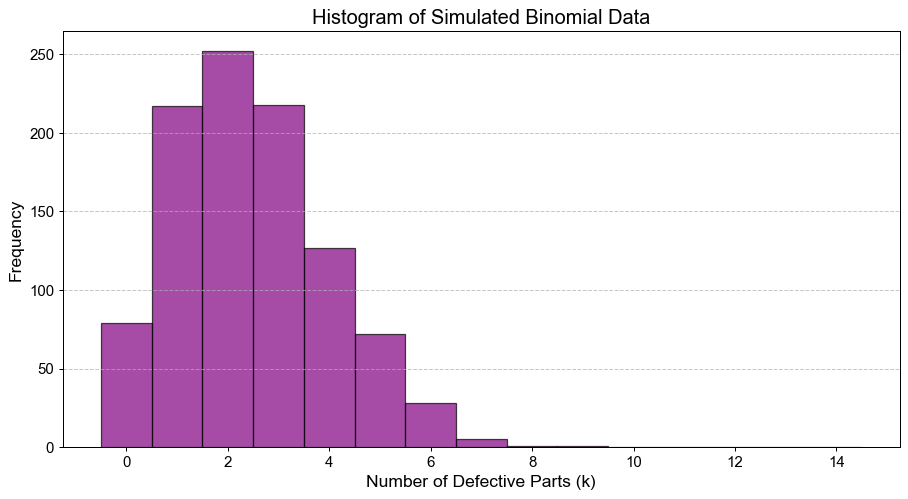

In [4]:
# Simulate random samples
np.random.seed(42)
samples = binom.rvs(n=50, p=0.05, size=1000)

# Plot histogram of simulated data
plt.figure(figsize=(12, 6))
plt.hist(samples, bins=np.arange(-0.5, 15.5, 1), color='purple', edgecolor='black', alpha=0.7)
plt.title('Histogram of Simulated Binomial Data', fontsize=16)
plt.xlabel('Number of Defective Parts (k)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_005.png)

直方图展示了 1000 次模拟数据的分布情况，与理论 PMF 分布高度一致。这说明模拟数据能够真实反映二项分布的特点。

##### Cumulative Distribution Function (CDF) 可视化

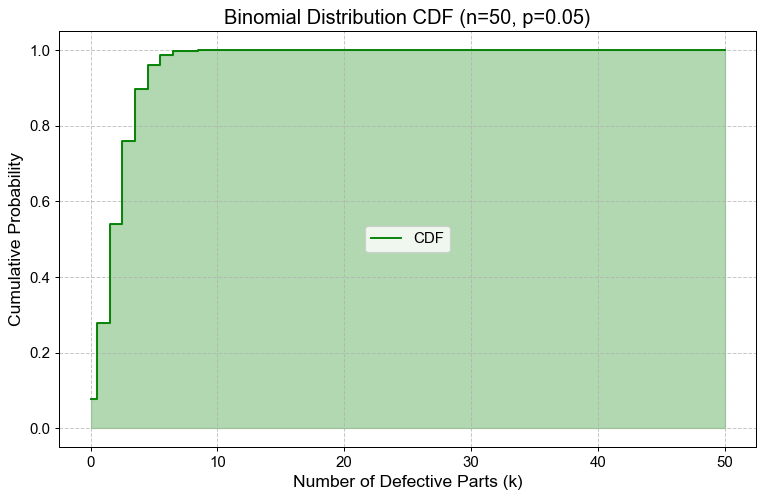

In [5]:
# Generate CDF
cdf = binom.cdf(x, n, p)

# Plotting CDF
plt.figure(figsize=(10, 6))
plt.step(x, cdf, where='mid', color='green', label='CDF')
plt.fill_between(x, cdf, step='mid', alpha=0.3, color='green')
plt.title('Binomial Distribution CDF (n=50, p=0.05)', fontsize=16)
plt.xlabel('Number of Defective Parts (k)', fontsize=14)
plt.ylabel('Cumulative Probability', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_006.png)

CDF 图显示了次品数量分布的累积概率。

例如，$P(X \leq 2)$ 表示次品数量不超过 2 的概率，容易从图中读取直观数值。

### 问题与讨论

通过以上分析，我们回答了以下问题：

1. **事件成功的期望值与分布规律是什么？**  
通过 PMF 和模拟数据，明确了成功事件的高频区域和分布趋势。
2. **罕见事件的概率如何计算？**  
CDF 提供了快速评估罕见事件（如 $P(X \geq 10)$）的工具。
3. **如何通过仿真验证分布模型的准确性？**  
使用随机生成数据对理论模型进行验证，确保分布的合理性。